In [8]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import copy
import matplotlib.pyplot as plt

random_seed = 1616
np.random.seed(random_seed)

# Defining FFNN code

In [9]:
class FFNN:
    def __init__(self, input_dim, layer_sizes, output_dim, learning_rate=0.01, epochs=10, batch_size=32,
                 early_stopping=False, patience=5, dropout_rates=None, random_seed=42):
        # Parameters ---------------------------------------------------------------------------------------------------- #
        self.learning_rate = learning_rate # Learning rate for updates during GD
        self.epochs = epochs # Number of epochs
        self.batch_size = batch_size # Number of sample in each batch during training

        # Early stopping ------------------------------------------------------------------------------------------------ #
        self.early_stopping = early_stopping 
        self.patience = patience # Number of epochs to wait ebfore stopping
        # Track best validation loss and patience counters for early stopping
        self.best_val_loss = float('inf')
        self.epochs_no_improve = 0
        self.best_weights = None
        self.best_biases = None

        # Controlled random generator
        self.rng = np.random.RandomState(random_seed)

        # Dropoout ------------------------------------------------------------------------------------------------------ #
        if dropout_rates is None:
            dropout_rates = [0.0] * len(layer_sizes)
        self.dropout_rates = dropout_rates # Probability of dropping a neuron output

        # Layer sizes --------------------------------------------------------------------------------------------------- #
        self.layer_sizes = [input_dim] + layer_sizes + [output_dim] # Define network structure

        # Initialize weights and biases --------------------------------------------------------------------------------- #
        self.weights = [ # He initialization
            np.random.normal(0, np.sqrt(2 / self.layer_sizes[i]), (self.layer_sizes[i], self.layer_sizes[i+1]))
            for i in range(len(self.layer_sizes) - 1)
        ]
        self.biases = [np.zeros((1, size)) for size in self.layer_sizes[1:]] # Biases initialized to 0
# ----------------------------------------------------------------------------------------------------------------------- #
    def relu(self, Z): # ReLU function
        return np.maximum(0, Z) # Returns Z where Z > 0, 0 where Z <= 0

    def relu_derivative(self, Z): # The derivative of ReLU
        return Z > 0 # Returns 1 where Z > 0 and 0 where Z <= 0
    
    def softmax(self, Z): # Softmax function
        exp_Z = np.exp(Z) 
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True) 
# ----------------------------------------------------------------------------------------------------------------------- #
    def forward_propagation(self, X, training=True):
        # For backpropagation later on:
        self.Z_temp = [] # List for Zs
        self.A_temp = [X] # List for As, starts with input X

        self.dropout_masks = []

        # Hidden Layers ------------------------------------------------------------------------------------------------- #
        A = X # Input data becomes the initial activation
        for i in range(len(self.weights) - 1): # Loop over all hidden layers
            Z = np.dot(A, self.weights[i]) + self.biases[i] # Z = A_prev * W + b
            A = self.relu(Z) # Apply ReLU: A = ReLU(Z)

            # Dropout in hidden layers
            rate = self.dropout_rates[i] # Get the dropout rate for the specific layer
            if training and rate > 0.0:
                # Create mask (1 where we keep neuron output, 0 where we drop)
                mask = (self.rng.rand(*A.shape) > rate).astype(np.float32)
                A *= mask # Drop neurons where mask is 0
                A /= (1.0 - rate) # scale the rest
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(None)


            self.Z_temp.append(Z) # Stores Zs for backpropagation
            self.A_temp.append(A) # Stores As for backpropagation

        # Output -------------------------------------------------------------------------------------------------------- #
        Z = np.dot(A, self.weights[-1]) + self.biases[-1] # Output layer
        A = self.softmax(Z) # Softmax applied in the output layer
        self.Z_temp.append(Z)
        self.A_temp.append(A)
        self.dropout_masks.append(None) # Not in output layer

        return A # Returns class probabilities

    def backward_propagation(self, X, y):
        m = X.shape[0] # Number of samples in the batch to account for batch size in gradient calculations
        # Gradient of Loss with respect to output layer activation
        dA = self.A_temp[-1] - y  # Gradient of loss function (cross entropy)

        # Gradients (will be stored in reverse order) ------------------------------------------------------------------ #
        dWs = [] # Gradients for weights
        dbs = [] # Gradients for biases

        # Backpropagation ---------------------------------------------------------------------------------------------- #
        for i in reversed(range(len(self.weights))): # Loop backward through all layers (start w output layer)
            dZ = dA # Gradient of loss wrt Z
            dW = np.dot(self.A_temp[i].T, dZ) / m # Gradient of loss wrt W
            db = np.sum(dZ, axis=0, keepdims=True) / m # Gradient of lsos wrt b
            dWs.insert(0, dW) # to maintain correct order
            dbs.insert(0, db) # insert at the beginning

            # Backpropagate to previous layer (for hidden layers only)
            if i > 0:
                dA = np.dot(dZ, self.weights[i].T) * self.relu_derivative(self.Z_temp[i-1])  # ReLU derivative

                # Reapply dropout in backpropagation so we only work with survived neurons
                mask = self.dropout_masks[i-1]
                rate = self.dropout_rates[i-1]

                if (mask is not None) and rate > 0.0:
                    dA *= mask
                    dA /= (1.0 - rate)

        # Gradient Descent updates  ------------------------------------------------------------------------------------- #
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * dWs[i] # Update weights
            self.biases[i] -= self.learning_rate * dbs[i] # Update biases
# ----------------------------------------------------------------------------------------------------------------------- #
    def train(self, X, y, validation_split=0.2): # Train the network, using validation split 80/20
        
        # Splitting the data
        num_samples = X.shape[0]
        split_index = int((1 - validation_split) * num_samples) # Finds the index at which to split the data

        # Shuffle the data before splitting 
        indexes = self.rng.permutation(num_samples)
        X, y = X[indexes], y[indexes] # Reorder data and their labels according to the shuffling

        # Split into training and validation sets
        X_train, X_val = X[:split_index], X[split_index:]
        y_train, y_val = y[:split_index], y[split_index:]

        # Store loss for plotting purposes
        self.train_loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            # Shuffle training data for mini-batches
            train_indexes = self.rng.permutation(X_train.shape[0]) # Training indexes
            X_train_shuffled = X_train[train_indexes] # Shuffled X data
            y_train_shuffled = y_train[train_indexes] # Shuffled y data

            # Iterate over the data in batches
            for batch_start in range(0, X_train.shape[0], self.batch_size):
                X_batch = X_train_shuffled[batch_start:batch_start+self.batch_size]
                y_batch = y_train_shuffled[batch_start:batch_start+self.batch_size]

                # Perform forward propagation
                self.forward_propagation(X_batch)
                # Perform backward propagation
                self.backward_propagation(X_batch, y_batch)

            # Evaluation ------------------------------------------------------------------------------------------------ #
            # Training data
            y_pred_train = self.forward_propagation(X_train)
            train_acc = self.calculate_accuracy(y_train, y_pred_train)
            train_loss = self.calculate_loss(y_train, y_pred_train)

            # Validation data
            y_pred_val = self.forward_propagation(X_val)
            val_acc = self.calculate_accuracy(y_val, y_pred_val)
            val_loss = self.calculate_loss(y_val, y_pred_val)

            # Append results
            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            # Prints metrics
            print(f"Epoch {epoch + 1}/{self.epochs}, "
                  f"accuracy: {train_acc:.4f}, loss: {train_loss:.4f}, "
                  f"val_accuracy: {val_acc:.4f}, val_loss: {val_loss:.4f}")
            
            # Early stopping -------------------------------------------------------------------------------------------- #
            if self.early_stopping:
                if val_loss < self.best_val_loss:
                    # improvement found
                    self.best_val_loss = val_loss
                    self.epochs_no_improve = 0
                    # Save best weights
                    self.best_weights = copy.deepcopy(self.weights)
                    self.best_biases = copy.deepcopy(self.biases)
                else:
                    self.epochs_no_improve += 1
                
                # Stop if no improvement for 'patience' epochs
                if self.epochs_no_improve >= self.patience:
                    print(f"Early stopping triggered at epoch {epoch + 1}")
                    # Optionally restore best weights
                    if self.best_weights is not None and self.best_biases is not None:
                        self.weights = self.best_weights
                        self.biases = self.best_biases
                    break
# ----------------------------------------------------------------------------------------------------------------------- #
    def calculate_loss(self, y, y_pred):
        # Cross entropy loss
        return -np.mean(np.sum(y * np.log(y_pred), axis=1))

    def calculate_accuracy(self, y, y_pred):
        # Calculate accuracy
        y_true = np.argmax(y, axis=1)
        y_pred_labels = np.argmax(y_pred, axis=1)
        return np.mean(y_true == y_pred_labels)

    def model_accuracy(self, X, y):
        # Calculate accuracy for the model
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def predict(self, X):
        # Predict class labels for inputs X
        probs = self.forward_propagation(X)
        return np.argmax(probs, axis=1)

    def label_encode(self, labels, num_classes):
        # Encode labels
        return np.eye(num_classes)[labels] # one-hot-encoding


# Model training

In [10]:
# Data Preparation ---------------------------------------------------------------------------------------------------- #
# Load data
train_data = np.load('fashion_train.npy')
test_data = np.load('fashion_test.npy')
# Split features and labels
X_train = train_data[:, :-1]
y_train = train_data[:, -1].astype(int) # Ensures class labels are integers
X_test = test_data[:, :-1]
y_test = test_data[:, -1].astype(int) # Ensures class labels are integers

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
n_components = 112
pca = PCA(n_components=n_components, random_state=1616)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# FFNN ---------------------------------------------------------------------------------------------------------------- #
# Initialize model
model = FFNN(input_dim=n_components, layer_sizes=[128, 64, 32, 16], output_dim=5, learning_rate=0.01, epochs=100, 
             batch_size=32, early_stopping=True, patience=5, dropout_rates=[0.2, 0.0, 0.0, 0.2], random_seed=1616)

# Encode labels
y_train_encoded = model.label_encode(y_train, 5)

# Train the network
model.train(X_train_pca, y_train_encoded)

Epoch 1/100, accuracy: 0.6664, loss: 0.8450, val_accuracy: 0.6570, val_loss: 0.8786
Epoch 2/100, accuracy: 0.7181, loss: 0.7206, val_accuracy: 0.7020, val_loss: 0.7582
Epoch 3/100, accuracy: 0.7465, loss: 0.6537, val_accuracy: 0.7190, val_loss: 0.6858
Epoch 4/100, accuracy: 0.7614, loss: 0.6190, val_accuracy: 0.7475, val_loss: 0.6480
Epoch 5/100, accuracy: 0.7745, loss: 0.5827, val_accuracy: 0.7615, val_loss: 0.6192
Epoch 6/100, accuracy: 0.7836, loss: 0.5508, val_accuracy: 0.7630, val_loss: 0.6010
Epoch 7/100, accuracy: 0.7895, loss: 0.5377, val_accuracy: 0.7610, val_loss: 0.5993
Epoch 8/100, accuracy: 0.7961, loss: 0.5294, val_accuracy: 0.7775, val_loss: 0.5824
Epoch 9/100, accuracy: 0.7971, loss: 0.5137, val_accuracy: 0.7830, val_loss: 0.5556
Epoch 10/100, accuracy: 0.8006, loss: 0.4939, val_accuracy: 0.7835, val_loss: 0.5490
Epoch 11/100, accuracy: 0.8129, loss: 0.4817, val_accuracy: 0.7845, val_loss: 0.5576
Epoch 12/100, accuracy: 0.8083, loss: 0.4828, val_accuracy: 0.7865, val_lo

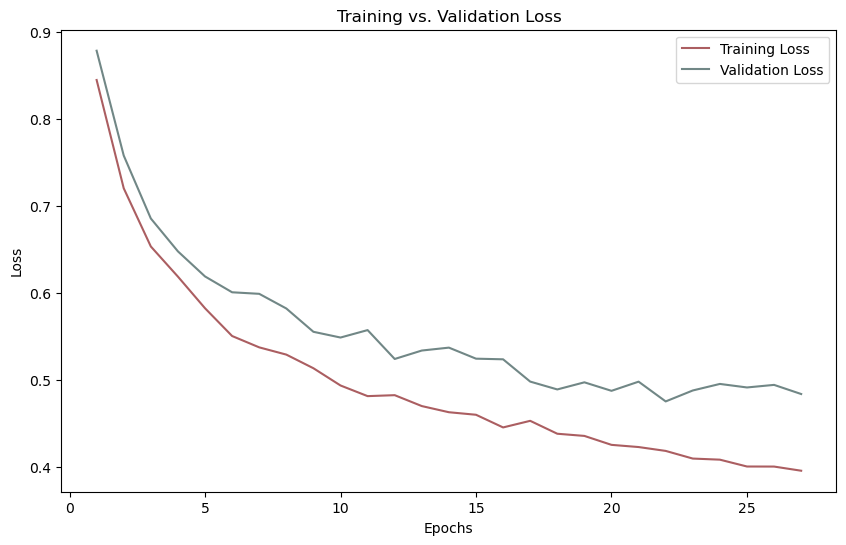

In [11]:
# Plot the loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(model.train_loss_history) + 1),
         model.train_loss_history, label='Training Loss', color='#AB5E61')
plt.plot(range(1, len(model.val_loss_history) + 1),
         model.val_loss_history, label='Validation Loss', color='#718786')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

# Model testing

In [12]:
# Model testing ------------------------------------------------------------------------------------------------------- #
# Test the model on the test data
test_accuracy = model.model_accuracy(X_test_pca, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

Test Accuracy: 0.80


## Classification report

In [13]:
def classification_report(y_true, y_pred, class_names):
    # Define classes ([0, 1, 2, 3, 4])
    classes = np.unique(np.concatenate([y_true, y_pred]))

    # Initialize lists to store metrics
    precision_list, recall_list, f1_list, support_list = [], [], [], []

    for k in classes: # Loop over classes
        TP = np.sum((y_pred == k) & (y_true == k)) # Prediction matches the true label for k
        FP = np.sum((y_pred == k) & (y_true != k)) # Prediction is k, but the true label is not k
        FN = np.sum((y_pred != k) & (y_true == k)) # Prediction is not k, but the true label is k
        support = np.sum(y_true == k) # Number of samples for class k

        # Precision, Recall, F1-score
        precision = TP / (TP + FP)
        recall = TP / (TP + FN)
        f1 = 2 * (precision * recall) / (precision + recall)

        # Append metrics
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        support_list.append(support)

    # Calculate overall metrics
    total_support = sum(support_list) # Total number of samples from all classes
    accuracy = np.sum(y_true == y_pred) / total_support
    # Macro = unweighted average of metrics across all classes
    macro_avg_precision = np.mean(precision_list)
    macro_avg_recall = np.mean(recall_list)
    macro_avg_f1 = np.mean(f1_list)
    # Weighted average of metrics across all classes
    weighted_avg_precision = np.average(precision_list, weights=support_list)
    weighted_avg_recall = np.average(recall_list, weights=support_list)
    weighted_avg_f1 = np.average(f1_list, weights=support_list)

    # Print report
    # Headers for columns
    print("Classification Report:")
    print(f"{'Class':<15}{'Precision':<10}{'Recall':<10}{'F1-Score':<10}{'Support':<10}")
    print("" * 60)
    # Print class specifics
    for i, k in enumerate(classes):
        print(f"{class_names[k]:<15}{precision_list[i]:<10.2f}{recall_list[i]:<10.2f}{f1_list[i]:<10.2f}{support_list[i]:<10}")
    print("" * 60)
    # Prints overall metrics
    print(f"{'Accuracy':<15}{accuracy:<10.2f}")
    print(f"{'Macro Avg':<15}{macro_avg_precision:<10.2f}{macro_avg_recall:<10.2f}{macro_avg_f1:<10.2f}{''}")
    print(f"{'Weighted Avg':<15}{weighted_avg_precision:<10.2f}{weighted_avg_recall:<10.2f}{weighted_avg_f1:<10.2f}{''}")


In [14]:
# Get predictions using the model
y_pred = model.predict(X_test_pca)
# Define the class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
# Display the classification report
classification_report(y_test, y_pred, class_names=class_names)


Classification Report:
Class          Precision Recall    F1-Score  Support   

T-shirt/top    0.78      0.73      0.76      1000      
Trouser        0.97      0.94      0.95      1000      
Pullover       0.83      0.75      0.79      1000      
Dress          0.86      0.85      0.85      1000      
Shirt          0.56      0.68      0.62      1000      

Accuracy       0.79      
Macro Avg      0.80      0.79      0.79      
Weighted Avg   0.80      0.79      0.79      
